### Sales Forecasting — Phase 2: ARIMA & SARIMA Baseline
### Rossmann Store Sales Dataset
 
Steps:
  1. Load Store 1 daily sales
  2. Stationarity check — ADF test
  3. Manual ARIMA — guided by Phase 1 ACF/PACF
  4. auto_arima — automated parameter search
  5. SARIMA — adds weekly seasonal component
  6. Evaluate on held-out last 6 weeks
  7. Forecast plot + residual diagnostics
  8. Save predictions for Phase 4 comparison

In [1]:
import statsmodels
import pmdarima as pm

print("statsmodels:", statsmodels.__version__)
print("pmdarima:", pm.__version__)

statsmodels: 0.14.6
pmdarima: 2.1.1


In [2]:
import pmdarima as pm

print("pmdarima imported successfully!")
print("Version:", pm.__version__)

pmdarima imported successfully!
Version: 2.1.1


In [7]:
import sys
import numpy
import scipy
import statsmodels
import sklearn

print("Python:", sys.version)
print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("Statsmodels:", statsmodels.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]
NumPy: 1.26.4
SciPy: 1.11.4
Statsmodels: 0.14.0
Scikit-learn: 1.9.0


In [9]:
!pip show pmdarima

Name: pmdarima
Version: 2.1.1
Summary: Python's forecast::auto.arima equivalent
Home-page: 
Author: 
Author-email: "Taylor G. Smith" <taylor.smith@alkaline-ml.com>
License: 
Location: C:\Users\Tammy\anaconda3\Lib\site-packages
Requires: Cython, joblib, numpy, packaging, pandas, scikit-learn, scipy, setuptools, statsmodels, urllib3
Required-by: 


In [10]:
import statsmodels
print(statsmodels.__version__)

from statsmodels.compat import scipy
print(scipy.__file__)

print(hasattr(scipy, "apply_where"))

0.14.0
c:\Users\Tammy\anaconda3\Lib\site-packages\statsmodels\compat\scipy.py
False


In [11]:
%pip install --upgrade statsmodels

In [4]:
!pip install --upgrade pmdarima

In [5]:
!pip install --upgrade statsmodels scipy

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import pmdarima as pm
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")
 
plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5", "grid.linewidth": 0.6})
 
STORE_ID  = 1
TEST_WEEKS = 6 

### LOAD DATA

In [5]:
ts = pd.read_csv(
    f"store_{STORE_ID}_daily_sales.csv",
    index_col=0,
    parse_dates=True
).squeeze("columns")


ts.index.freq = "D"
ts.name = "Sales"
 
print("=" * 60)
print(f"STORE {STORE_ID} — TIME SERIES")
print("=" * 60)
print(f"Length     : {len(ts)} days")
print(f"Date range : {ts.index.min().date()} → {ts.index.max().date()}")
print(f"Mean sales : €{ts.mean():,.0f}")
print(f"Std        : €{ts.std():,.0f}")
print(f"Skewness   : {ts.skew():.3f}")
 
# Log-transform to stabilise variance (multiplicative seasonality)
ts_log = np.log1p(ts)
 
# ── Train / test split — time-aware, NEVER shuffle ───────────────────────
test_days  = TEST_WEEKS * 7
train      = ts.iloc[:-test_days]
test       = ts.iloc[-test_days:]
train_log  = ts_log.iloc[:-test_days]
test_log   = ts_log.iloc[-test_days:]
 
print(f"\nTrain : {len(train)} days  ({train.index.min().date()} → "
      f"{train.index.max().date()})")
print(f"Test  : {len(test)} days   ({test.index.min().date()} → "
      f"{test.index.max().date()})")
print(f"\nTime-aware split — train on the past, test on the future.")
print(f"Never shuffle time series data before splitting.")

STORE 1 — TIME SERIES
Length     : 941 days
Date range : 2013-01-02 → 2015-07-31
Mean sales : €4,792
Std        : €1,005
Skewness   : 0.876

Train : 899 days  (2013-01-02 → 2015-06-19)
Test  : 42 days   (2015-06-20 → 2015-07-31)

Time-aware split — train on the past, test on the future.
Never shuffle time series data before splitting.


###  STATIONARITY — ADF TEST

In [6]:
def adf_report(series, label):
    result = adfuller(series.dropna(), autolag="AIC")
    stat, p, _, _, crit, _ = result
    stationary = p < 0.05
    print(f"  {label:<30} ADF={stat:.4f}  p={p:.4f}  "
          f"{'✓ Stationary' if stationary else '✗ Non-stationary'}")
    return stationary
 
print("\nADF stationarity test:")
orig_stat  = adf_report(train_log, "Log-sales (original)")
diff1_stat = adf_report(train_log.diff().dropna(), "Log-sales (1st diff)")
diff7_stat = adf_report(train_log.diff(7).dropna(), "Log-sales (seasonal diff)")
 
d  = 0 if orig_stat else 1
D  = 0 if diff7_stat else 1
print(f"\n  Suggested d={d}  D={D}  (use in ARIMA/SARIMA below)")


ADF stationarity test:
  Log-sales (original)           ADF=-5.7773  p=0.0000  ✓ Stationary
  Log-sales (1st diff)           ADF=-10.5089  p=0.0000  ✓ Stationary
  Log-sales (seasonal diff)      ADF=-9.5449  p=0.0000  ✓ Stationary

  Suggested d=0  D=0  (use in ARIMA/SARIMA below)


###  EVALUATION METRICS

In [7]:
def evaluate(actual, predicted, label):
    """Compute MAPE, RMSE, MAE on original (non-log) scale."""
    actual    = np.array(actual)
    predicted = np.array(predicted)
    # Clip to avoid div-by-zero
    mask   = actual > 0
    mape   = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    rmse   = np.sqrt(mean_squared_error(actual, predicted))
    mae    = mean_absolute_error(actual, predicted)
    print(f"  {label:<28}  MAPE={mape:.2f}%  RMSE=€{rmse:,.0f}  MAE=€{mae:,.0f}")
    return {"label": label, "MAPE": round(mape, 2),
            "RMSE": round(rmse, 0), "MAE": round(mae, 0)}
 
results = []

### MANUAL ARIMA

In [8]:
#    PACF cuts off at lag 1-2 → p=2
#    ACF cuts off at lag 1    → q=1
#    d=1 if non-stationary

 
print("\n── Manual ARIMA ──────────────────────────────────────")
p, q = 2, 1
 
arima_model = ARIMA(train_log, order=(p, d, q))
arima_fit   = arima_model.fit()
 
print(f"  Order: ({p},{d},{q})")
print(f"  AIC  : {arima_fit.aic:.2f}")
print(f"  BIC  : {arima_fit.bic:.2f}")
 
# Forecast on test period
arima_forecast_log = arima_fit.forecast(steps=test_days)
arima_forecast     = np.expm1(arima_forecast_log)
 
results.append(evaluate(test.values, arima_forecast.values,
                         f"ARIMA({p},{d},{q})"))


── Manual ARIMA ──────────────────────────────────────
  Order: (2,0,1)
  AIC  : -940.60
  BIC  : -916.60
  ARIMA(2,0,1)                  MAPE=15.59%  RMSE=€749  MAE=€628


### AUTO_ARIMA - AUTOMATED PARAMETER SEARCH

In [9]:
print("\n── auto_arima ────────────────────────────────────────")
print("  Searching for optimal (p,d,q) — may take ~30 seconds...")
 
auto_model = pm.auto_arima(
    train_log,
    start_p=0, max_p=4,
    start_q=0, max_q=4,
    d=d,
    seasonal=False,
    stepwise=True,
    information_criterion="aic",
    error_action="ignore",
    suppress_warnings=True,
)
 
best_order = auto_model.order
print(f"  Best order: {best_order}")
print(f"  AIC       : {auto_model.aic():.2f}")
 
auto_forecast_log = auto_model.predict(n_periods=test_days)
auto_forecast     = np.expm1(auto_forecast_log)
 
results.append(evaluate(test.values, auto_forecast,
                         f"auto_ARIMA{best_order}"))


── auto_arima ────────────────────────────────────────
  Searching for optimal (p,d,q) — may take ~30 seconds...
  Best order: (1, 0, 0)
  AIC       : -944.60
  auto_ARIMA(1, 0, 0)           MAPE=15.59%  RMSE=€749  MAE=€629


### SARIMA — SEASONAL ARIMA

In [10]:
#    Adds weekly seasonal component (s=7)
#    Captures day-of-week pattern that plain ARIMA misses
#    Order: (p,d,q)(P,D,Q,s)
# ════════════════════════════════════════════════════════════════════════════
 
print("\n── SARIMA ────────────────────────────────────────────")
print("  Adding weekly seasonal component (s=7)...")
 
# Seasonal order — P=1, D=1, Q=1 is a common starting point
P, Q_s = 1, 1
sarima_order = (p, d, q)
seasonal_order = (P, D, Q_s, 7)
 
sarima_model = SARIMAX(train_log,
                       order=sarima_order,
                       seasonal_order=seasonal_order,
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
 
print(f"  Order    : {sarima_order}")
print(f"  Seasonal : {seasonal_order}")
print(f"  AIC      : {sarima_fit.aic:.2f}")
print(f"  BIC      : {sarima_fit.bic:.2f}")
 
sarima_forecast_log = sarima_fit.forecast(steps=test_days)
sarima_forecast     = np.expm1(sarima_forecast_log)
 
results.append(evaluate(test.values, sarima_forecast.values,
                         f"SARIMA{sarima_order}{seasonal_order}"))
 


── SARIMA ────────────────────────────────────────────
  Adding weekly seasonal component (s=7)...
  Order    : (2, 0, 1)
  Seasonal : (1, 0, 1, 7)
  AIC      : -994.68
  BIC      : -965.93
  SARIMA(2, 0, 1)(1, 0, 1, 7)   MAPE=14.74%  RMSE=€708  MAE=€621


###  AUTO SARIMA — BEST SEASONAL MODEL

In [11]:
print("\n── auto_arima (seasonal) ─────────────────────────────")
print("  Searching seasonal orders — may take ~60 seconds...")
 
auto_sarima = pm.auto_arima(
    train_log,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=d,
    seasonal=True, m=7,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=D,
    stepwise=True,
    information_criterion="aic",
    error_action="ignore",
    suppress_warnings=True,
)
 
best_sarima_order   = auto_sarima.order
best_seasonal_order = auto_sarima.seasonal_order
print(f"  Best order    : {best_sarima_order}")
print(f"  Best seasonal : {best_seasonal_order}")
print(f"  AIC           : {auto_sarima.aic():.2f}")
 
auto_sarima_log = auto_sarima.predict(n_periods=test_days)
auto_sarima_fc  = np.expm1(auto_sarima_log)
 
best_label = f"auto_SARIMA{best_sarima_order}{best_seasonal_order}"
results.append(evaluate(test.values, auto_sarima_fc, best_label))


── auto_arima (seasonal) ─────────────────────────────
  Searching seasonal orders — may take ~60 seconds...
  Best order    : (1, 0, 0)
  Best seasonal : (0, 0, 0, 7)
  AIC           : -944.60
  auto_SARIMA(1, 0, 0)(0, 0, 0, 7)  MAPE=15.59%  RMSE=€749  MAE=€629


###  COMPARISON TABLE

In [12]:
results_df = pd.DataFrame(results).sort_values("MAPE")
print("\n" + "=" * 60)
print("ARIMA MODEL COMPARISON  (sorted by MAPE)")
print("=" * 60)
print(results_df.to_string(index=False))
best_model_label = results_df.iloc[0]["label"]
best_mape        = results_df.iloc[0]["MAPE"]
print(f"\n✓ Best: {best_model_label}  MAPE={best_mape:.2f}%")
 
# Pick best forecast for downstream plots
forecasts = {
    f"ARIMA({p},{d},{q})"   : arima_forecast.values,
    f"auto_ARIMA{best_order}": auto_forecast,
    f"SARIMA"               : sarima_forecast.values,
    best_label              : auto_sarima_fc,
}
best_fc = forecasts[best_model_label] \
    if best_model_label in forecasts else auto_sarima_fc


ARIMA MODEL COMPARISON  (sorted by MAPE)
                           label  MAPE  RMSE   MAE
     SARIMA(2, 0, 1)(1, 0, 1, 7) 14.74 708.0 621.0
                    ARIMA(2,0,1) 15.59 749.0 628.0
             auto_ARIMA(1, 0, 0) 15.59 749.0 629.0
auto_SARIMA(1, 0, 0)(0, 0, 0, 7) 15.59 749.0 629.0

✓ Best: SARIMA(2, 0, 1)(1, 0, 1, 7)  MAPE=14.74%


### FORECAST PLOT

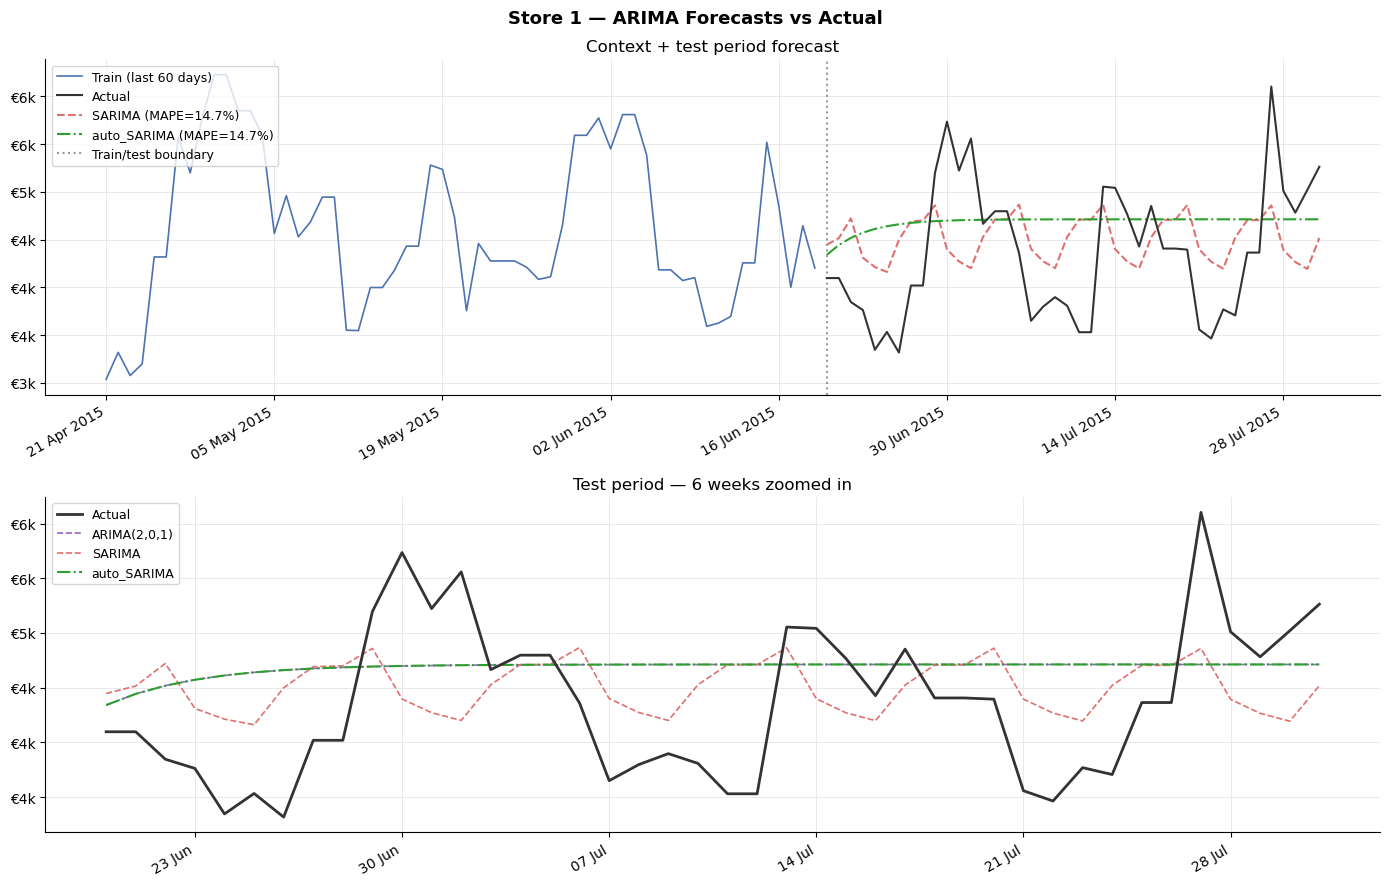

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle(f"Store {STORE_ID} — ARIMA Forecasts vs Actual",
             fontweight="bold", fontsize=13)
 
# Panel 1: Full context + forecast
ax = axes[0]
context_days = 60   # show last 60 train days for context
ax.plot(train.index[-context_days:],
        train.values[-context_days:],
        color="#4C72B0", linewidth=1.2, label="Train (last 60 days)")
ax.plot(test.index, test.values,
        color="#333", linewidth=1.5, label="Actual", zorder=5)
ax.plot(test.index, sarima_forecast.values,
        color="#E07070", linewidth=1.5, linestyle="--",
        label=f"SARIMA (MAPE={results_df[results_df['label'].str.startswith('SARIMA')]['MAPE'].values[0]:.1f}%)")
ax.plot(test.index, auto_sarima_fc,
        color="#2ca02c", linewidth=1.5, linestyle="-.",
        label=f"{best_label.split('(')[0]} (MAPE={best_mape:.1f}%)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.axvline(test.index[0], color="#999", linestyle=":",
           linewidth=1.5, label="Train/test boundary")
ax.set_title("Context + test period forecast")
ax.legend(fontsize=9, loc="upper left")
 
# Panel 2: Test period only — zoomed in
ax2 = axes[1]
ax2.plot(test.index, test.values,
         color="#333", linewidth=2, label="Actual", zorder=5)
ax2.plot(test.index, arima_forecast.values,
         color="#9467BD", linewidth=1.2, linestyle="--",
         label=f"ARIMA({p},{d},{q})")
ax2.plot(test.index, sarima_forecast.values,
         color="#E07070", linewidth=1.2, linestyle="--", label="SARIMA")
ax2.plot(test.index, auto_sarima_fc,
         color="#2ca02c", linewidth=1.5, linestyle="-.", label=best_label.split("(")[0])
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax2.set_title(f"Test period — {TEST_WEEKS} weeks zoomed in")
ax2.legend(fontsize=9, loc="upper left")
 
plt.tight_layout()
plt.savefig("phase2_forecast.png", dpi=150, bbox_inches="tight")
plt.show()


### RESIDUAL DIAGNOSTICS — BEST MODEL

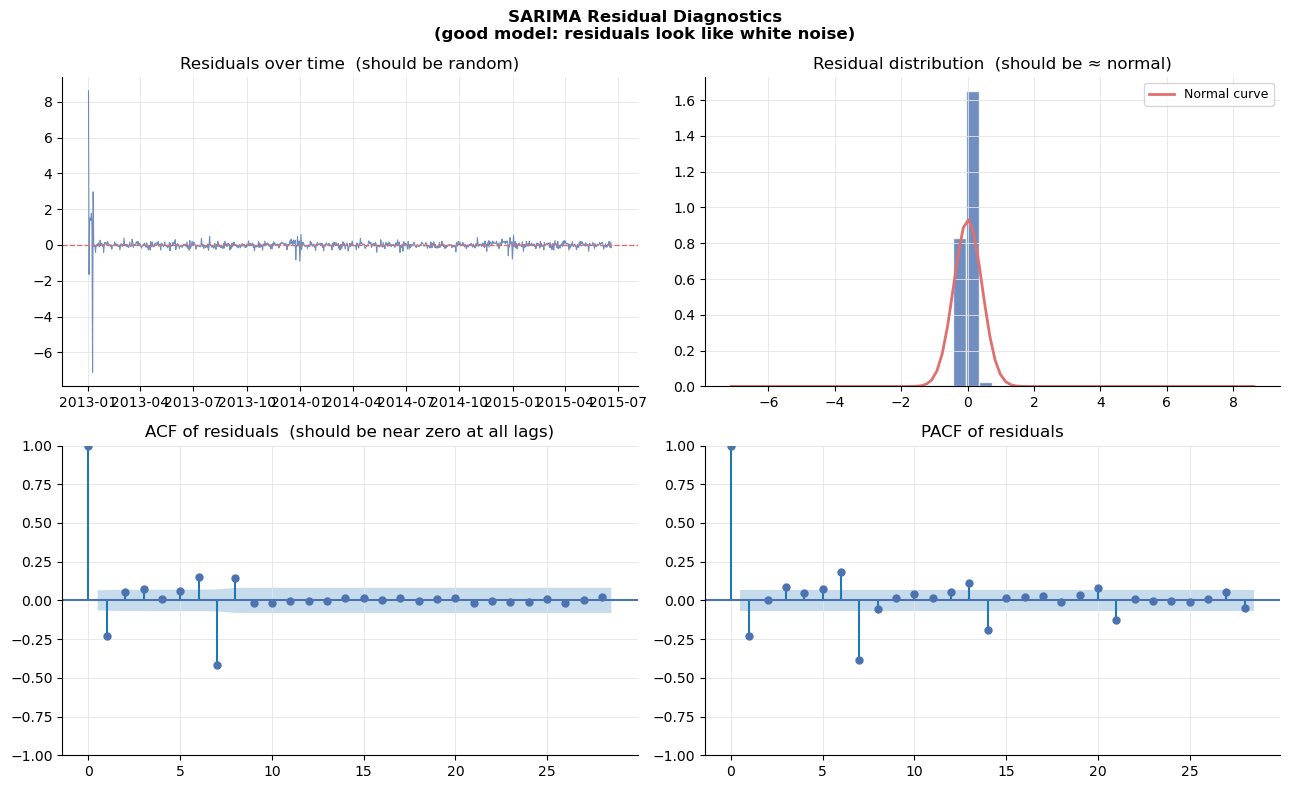


Ljung-Box test (H0: residuals are white noise):
     lb_stat  lb_pvalue
7   235.5275        0.0
14  255.5722        0.0
21  256.5061        0.0

  p > 0.05 at all lags = residuals are white noise = good model fit


In [14]:
residuals = sarima_fit.resid
 
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("SARIMA Residual Diagnostics\n"
             "(good model: residuals look like white noise)",
             fontweight="bold", fontsize=12)
 
# Panel 1: Residuals over time
ax = axes[0, 0]
ax.plot(residuals.index, residuals.values,
        color="#4C72B0", linewidth=0.8, alpha=0.8)
ax.axhline(0, color="#E07070", linestyle="--", linewidth=1)
ax.set_title("Residuals over time  (should be random)")
ax.set_xlabel("")
 
# Panel 2: Residual histogram
ax2 = axes[0, 1]
ax2.hist(residuals, bins=40, color="#4C72B0",
         edgecolor="white", density=True, alpha=0.8)
mu, std = residuals.mean(), residuals.std()
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
ax2.plot(x_norm, 1/(std * np.sqrt(2*np.pi)) * np.exp(-0.5*((x_norm-mu)/std)**2),
         color="#E07070", linewidth=2, label="Normal curve")
ax2.set_title("Residual distribution  (should be ≈ normal)")
ax2.legend(fontsize=9)
 
# Panel 3: ACF of residuals
plot_acf(residuals, lags=28, ax=axes[1, 0],
         color="#4C72B0", alpha=0.05)
axes[1, 0].set_title("ACF of residuals  (should be near zero at all lags)")
 
# Panel 4: PACF of residuals
plot_pacf(residuals, lags=28, ax=axes[1, 1],
          color="#4C72B0", method="ywm", alpha=0.05)
axes[1, 1].set_title("PACF of residuals")
 
plt.tight_layout()
plt.savefig("phase2_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
 
# Ljung-Box test: are residuals white noise?
lb_test = acorr_ljungbox(residuals, lags=[7, 14, 21], return_df=True)
print(f"\nLjung-Box test (H0: residuals are white noise):")
print(lb_test.round(4).to_string())
print(f"\n  p > 0.05 at all lags = residuals are white noise = good model fit")

In [15]:
# SAVE PREDICTIONS FOR PHASE 4
 
arima_preds_df = pd.DataFrame({
    "Date"          : test.index,
    "Actual"        : test.values,
    "SARIMA_pred"   : sarima_forecast.values,
    "AutoSARIMA_pred": auto_sarima_fc,
})
arima_preds_df.to_csv("arima_predictions.csv", index=False)
print(f"\nSaved: arima_predictions.csv  ← used in Phase 4 comparison")


Saved: arima_predictions.csv  ← used in Phase 4 comparison
